In [2]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, OneHotEncoder
import numpy as np

In [3]:
df = pd.read_csv(r"C:\Users\Test\Desktop\PySpiders\Machine_Learning\Datasets\loan_data.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [5]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [6]:
X = df.drop(columns='loan_status')
y = df['loan_status']

In [7]:
X.corr(numeric_only= True)

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
person_age,1.000000,0.193698,0.954412,0.050750,0.013402,-0.043299,0.861985,0.178432
person_income,0.193698,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919
person_emp_exp,0.954412,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196
loan_amnt,0.050750,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074
loan_int_rate,0.013402,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498
loan_percent_income,-0.043299,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483
cb_person_cred_hist_length,0.861985,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204
credit_score,0.178432,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000


In [8]:
xtrain, xtest, ytrain, ytest = train_test_split(X,y,train_size = 0.8, random_state=42)

In [9]:
num_col = X.select_dtypes(include='number').columns
obj_col = X.select_dtypes(include='str').columns

<Axes: >

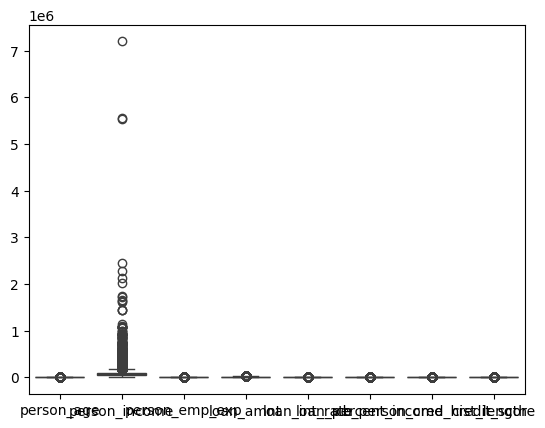

In [10]:
sns.boxplot(X[num_col])

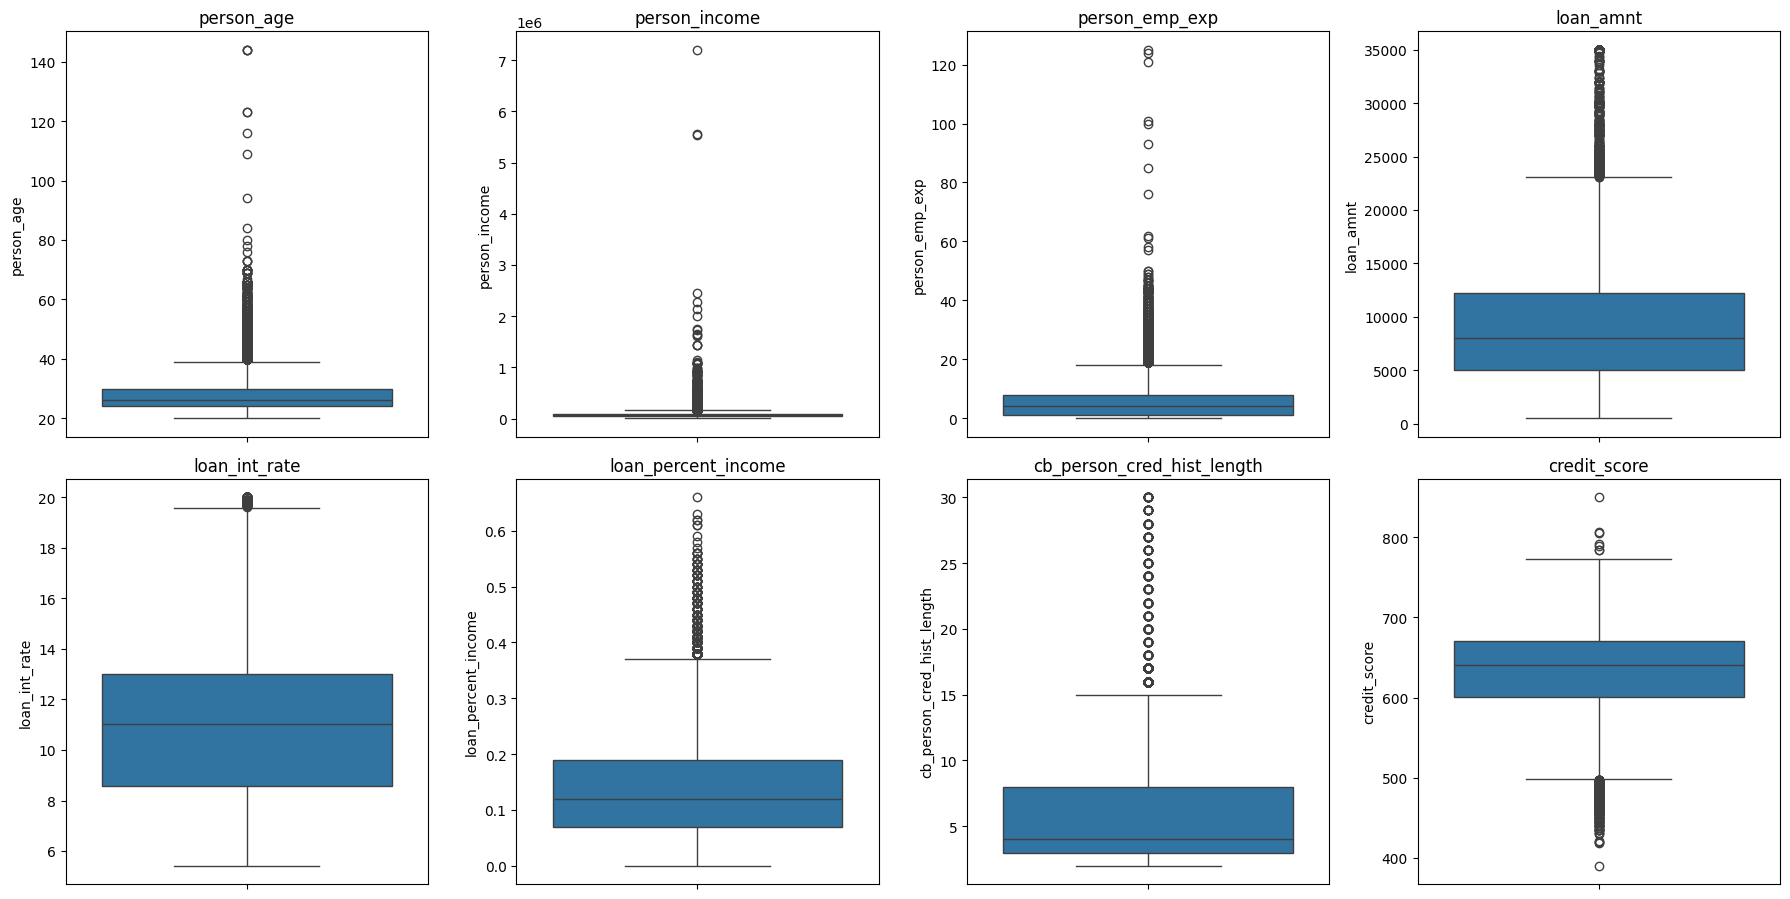

In [11]:
plt.figure(figsize=(18,18))
for i, col in enumerate(num_col):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()

In [12]:
X[obj_col].nunique()

person_gender                     2
person_education                  5
person_home_ownership             4
loan_intent                       6
previous_loan_defaults_on_file    2
dtype: int64

- scaling - we can use robust scaling because we have more number of outliers
- encoding - we can use onehot encoder because we have more feature columns and they have less unique values

In [13]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
scaling = RobustScaler()
model = LogisticRegression(penalty='l2',solver='liblinear')

In [14]:
# update xtrain
xtrain[num_col] = scaling.fit_transform(xtrain[num_col])

encoded_values = encoder.fit_transform(xtrain[obj_col])
encoded_columns = encoder.get_feature_names_out()
xtrain[encoded_columns] = encoded_values
xtrain.drop(columns=obj_col,inplace=True)

In [15]:
xtrain

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_female,person_gender_male,...,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
25180,1.333333,0.621771,1.000000,0.965517,0.386517,0.250000,1.0,-0.132353,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
12555,-0.166667,0.120777,-0.142857,0.551724,0.191011,0.333333,0.0,0.279412,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
29153,2.500000,5.265159,2.000000,2.206897,-0.143820,-0.416667,1.4,0.632353,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
23838,0.166667,0.559271,0.000000,0.220690,1.377528,-0.166667,0.6,0.014706,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
35686,0.166667,0.366411,0.428571,-0.129793,0.440449,-0.333333,-0.2,0.970588,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.000000,0.440142,0.285714,0.362069,-1.119101,0.000000,0.0,-1.191176,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
44732,-0.166667,-0.666014,-0.142857,-0.292966,0.152809,0.416667,0.0,0.102941,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
38158,1.166667,-0.180825,0.714286,0.373379,-0.060674,0.500000,1.0,0.176471,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
860,0.000000,2.297872,0.285714,1.655172,1.568539,-0.083333,-0.2,-0.529412,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [16]:
#update xtest
xtest[num_col] = scaling.transform(xtest[num_col])

xtest_encoded_values = encoder.transform(xtest[obj_col])
xtest[encoded_columns] = xtest_encoded_values
xtest.drop(columns=obj_col,inplace=True)

In [17]:
xtest

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_female,person_gender_male,...,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
37979,1.000000,0.613528,0.857143,-0.068966,-1.116854,-0.333333,1.2,-0.573529,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9911,-0.333333,-0.211303,0.285714,0.137931,0.107865,0.333333,0.0,0.102941,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
43386,-0.666667,-0.613961,-0.571429,-0.413793,0.869663,0.083333,0.0,1.044118,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
13822,-0.500000,-0.559435,-0.428571,-0.413793,0.669663,0.083333,-0.2,-0.632353,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
44810,2.666667,0.018175,2.285714,0.275862,0.988764,0.250000,1.4,-0.794118,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14572,-0.833333,1.362382,-0.571429,0.827586,-0.229213,-0.083333,-0.4,0.205882,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
30384,2.166667,-0.107218,1.857143,-0.175862,1.222472,-0.083333,1.4,-0.500000,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
36665,-0.333333,0.244356,-0.428571,0.827586,0.143820,0.500000,-0.2,-0.382353,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
30569,2.000000,-0.617176,1.714286,0.000000,0.000000,0.833333,2.0,0.808824,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [18]:
model.fit(xtrain,ytrain)

c:\Users\Test\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [19]:
ytrain_pred = model.predict(xtrain)
ytest_pred = model.predict(xtest)

# Train data Evaluation

In [20]:
y.value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

In [21]:
ytrain.value_counts()

loan_status
0    28010
1     7990
Name: count, dtype: int64

In [22]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, recall_score, precision_score

# Confusion Matrix

In [23]:
matrix = confusion_matrix(ytrain, ytrain_pred)
matrix

array([[26318,  1692],
       [ 2002,  5988]])

**Conclusion for confusion matrix**
* Out of 403 yes labels

# Precision Score

In [24]:
precision_score(ytrain, ytrain_pred)

0.7796875

In [25]:
predicted_1 = np.sum(matrix[:,1])
predicted_1

np.int64(7680)

**Conclusion for precision score '1'**
* out of all the predicted '1' labels(7682) , 77% labels are correctly predicted as '1' 
* out of all the predicted '1' labels(7682) , 33% labels are wrongly predicted as '1' 

In [26]:
precision_score(ytrain, ytrain_pred, pos_label=1)

0.7796875

In [27]:
predicted_0 = np.sum(matrix[:,0])
predicted_0

np.int64(28320)

**Conclusion for precision score '0'**
* out of all the predicted '0' labels(28318) , 77.9% labels are correctly predicted as '0' 
* out of all the predicted '0' labels(28318) , 33% labels are wrongly predicted as '0'

# Recall Score

In [28]:
recall_score(ytrain, ytrain_pred)

0.7494367959949937

**Conclusion For Recall Score '1'**
* out of all the actual '1' labels(7990) , 74.9% labels are correctly predicted as '1' 
* out of all the actual '1' labels(7990) , 24.1% labels are wrongly predicted as '0' 

In [29]:
recall_score(ytrain, ytrain_pred, pos_label=0)

0.9395930024991075

**Conclusion For Recall Score '0'**
* out of all the actual '0' labels(28010) , 93.9% labels are correctly predicted as '0' 
* out of all the actual '0' labels(28010) , 6.1% labels are wrongly predicted as '1' 

# Accuracy Score

In [30]:
accuracy_score(ytrain, ytrain_pred)

0.8973888888888889

**Conclusion for Accuracy score**
* out of all the samples(36000), 89.7% samples are correctly predicted

# F1 Score

In [31]:
f1_score(ytrain, ytrain_pred)

0.7642629227823867

# Test Data Evaluation

In [32]:
ytest.value_counts()

loan_status
0    6990
1    2010
Name: count, dtype: int64

# Confusion matrix

In [33]:
matrix = confusion_matrix(ytest, ytest_pred)
matrix

array([[6560,  430],
       [ 519, 1491]])

# Precision Score

In [34]:
precision_score(ytest, ytest_pred)

0.7761582509109839

In [35]:
predicted_1 = np.sum(matrix[:,1])
predicted_1

np.int64(1921)

**Conclusion for precision score '1'**
* out of all the predicted '1' labels(1924) , 77.5% labels are correctly predicted as '1' 
* out of all the predicted '1' labels(1924) , 32.5% labels are wrongly predicted as '1' 

In [36]:
precision_score(ytest, ytest_pred, pos_label=0)

0.9266845599660969

In [37]:
predicted_0 = np.sum(matrix[:,0])
predicted_0

np.int64(7079)

**Conclusion for precision score '0'**
* out of all the predicted '0' labels(7076) , 92.66% labels are correctly predicted as '0' 
* out of all the predicted '0' labels(7076) , 7.44% labels are wrongly predicted as '0'

# Recall

In [38]:
recall_score(ytest, ytest_pred)

0.7417910447761195

**Conclusion For Recall Score '1'**
* out of all the actual '1' labels(2010) , 74.17% labels are correctly predicted as 'yes' 
* out of all the actual '1' labels(2010) , 35.83% labels are wrongly predicted as 'No' 

In [39]:
recall_score(ytest, ytest_pred, pos_label=0)

0.9384835479256081

**Conclusion For Recall Score '0'**
* out of all the actual '0' labels(95) , 93.8% labels are correctly predicted as '0' 
* out of all the actual '0' labels(95) , 6.2% labels are wrongly predicted as '1' 

# Accuracy

In [40]:
accuracy_score(ytest, ytest_pred)

0.8945555555555555

**Conclusion for Accuracy score**
* out of all the samples(9000), 89.4% samples are correctly predicted

# F1 Score

In [41]:
f1_score(ytest, ytest_pred)

0.7585856016280844

# Final Conclusion
* Model Performance is good, so the model has learned the train and test data pattern well
* The model is good fit

In [42]:
from sklearn.metrics import classification_report

In [43]:
print(classification_report(ytrain, ytrain_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93     28010
           1       0.78      0.75      0.76      7990

    accuracy                           0.90     36000
   macro avg       0.85      0.84      0.85     36000
weighted avg       0.90      0.90      0.90     36000

